In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [32]:
df=pd.read_csv('churn_prob.csv')

In [33]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Probability
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0.830306
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,0.107333
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0.552782
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0.062844
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0.849347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0,0.286183
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0,0.358950
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,0.607900
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1,0.893700


In [34]:
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_Probability"
]

In [35]:
from sklearn.preprocessing import StandardScaler

segment_data = df[features]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_data)

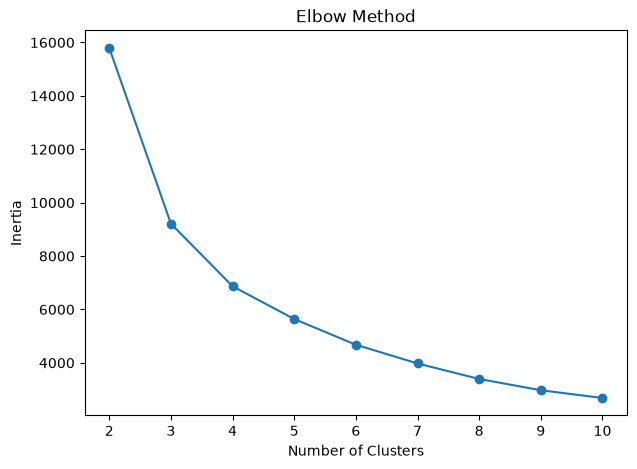

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [37]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Segment"] = kmeans.fit_predict(scaled_data)

In [38]:
df.groupby("Segment")[features].mean().round(2)

,tenure,MonthlyCharges,TotalCharges,Churn_Probability
Segment,,,,
0,60.38,93.58,5654.21,0.27
1,9.28,35.82,352.34,0.45
2,48.23,37.71,1770.57,0.08
3,14.93,83.83,1299.12,0.76


In [39]:
segment_names = {
    0: "High-Value Loyal Customers",
    1: "New Low-Value Customers",
    2: "Stable Low-Spending Customers",
    3: "High-Risk Premium Customers"
}

df["Segment_Name"] = df["Segment"].map(segment_names)

In [40]:
df["Segment_Name"].value_counts()

Segment_Name
High-Risk Premium Customers      2038
High-Value Loyal Customers       1785
New Low-Value Customers          1682
Stable Low-Spending Customers    1538
Name: count, dtype: int64

In [41]:
(df["Segment_Name"].value_counts(normalize=True) * 100).round(2)

Segment_Name
High-Risk Premium Customers      28.94
High-Value Loyal Customers       25.34
New Low-Value Customers          23.88
Stable Low-Spending Customers    21.84
Name: proportion, dtype: float64

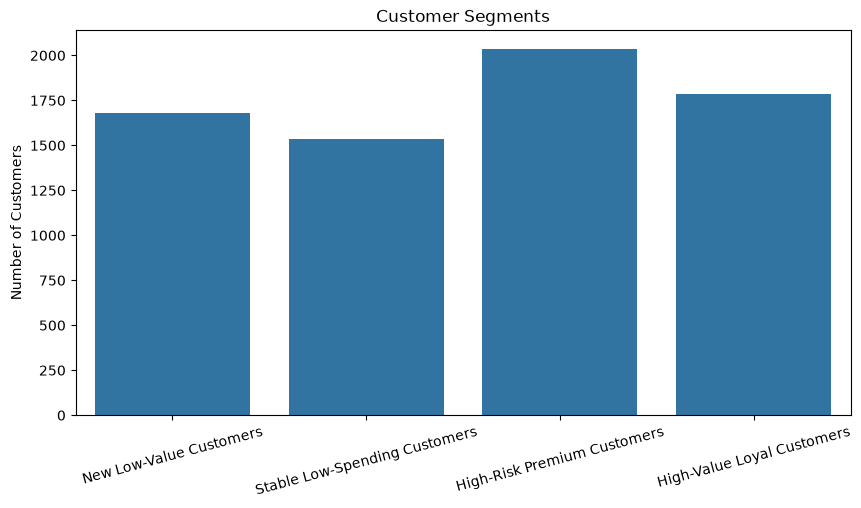

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Segment_Name",
)

plt.title("Customer Segments")
plt.xlabel("")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

In [43]:
df["Risk_Level"] = pd.cut(
    df["Churn_Probability"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low", "Medium", "High"]
)

In [44]:
high = df["MonthlyCharges"].quantile(0.75)
medium = df["MonthlyCharges"].quantile(0.40)

def revenue_category(row):

    if row["MonthlyCharges"] >= high:
        return "High Revenue"

    elif row["MonthlyCharges"] >= medium:
        return "Medium Revenue"

    else:
        return "Low Revenue"

df["Revenue_Category"] = df.apply(revenue_category, axis=1)

In [45]:
def priority(prob):
    if prob >= 0.7:
        return "Critical"
    elif prob >= 0.4:
        return "High"
    else:
        return "Normal"

df["Priority"] = df["Churn_Probability"].apply(priority)

In [46]:
def retention_action(row):

    if row["Segment_Name"] == "High-Risk Premium Customers":
        return "Offer 20% Bill Discount + Priority Support"

    elif row["Segment_Name"] == "High-Value Loyal Customers":
        return "VIP Rewards & Loyalty Benefits"

    elif row["Segment_Name"] == "Stable Low-Spending Customers":
        return "Upsell Affordable Add-on Plans"

    elif row["Segment_Name"] == "New Low-Value Customers":
        return "Welcome Offer + Service Education"

    else:
        return "Regular Customer Engagement"
    
df["Retention_Action"] = df.apply(retention_action, axis=1)

In [47]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,Churn_Probability,Segment,Segment_Name,Risk_Level,Revenue_Category,Priority,Retention_Action
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,29.85,29.85,0,0.830306,1,New Low-Value Customers,High,Low Revenue,Critical,Welcome Offer + Service Education
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,56.95,1889.50,0,0.107333,2,Stable Low-Spending Customers,Low,Low Revenue,Normal,Upsell Affordable Add-on Plans
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,53.85,108.15,1,0.552782,1,New Low-Value Customers,Medium,Low Revenue,High,Welcome Offer + Service Education
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,42.30,1840.75,0,0.062844,2,Stable Low-Spending Customers,Low,Low Revenue,Normal,Upsell Affordable Add-on Plans
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,70.70,151.65,1,0.849347,3,High-Risk Premium Customers,High,Medium Revenue,Critical,Offer 20% Bill Discount + Priority Support


In [49]:
df.to_csv("Final_Segments.csv", index=False)